# TabICL Survival: Wrapper Demo and Benchmark Comparison

This notebook is a compact end-to-end walkthrough for the survival extension:

1. Generate a synthetic Weibull proportional-hazards survival task.
2. Fit the sklearn-style `TabICLSurvivalEstimator` on the context set.
3. Inspect unconditional survival curves, conditional survival after a landmark time, and quantile predictions.
4. Compare TabICL with oracle, non-parametric, semi-parametric, correctly specified parametric, and misspecified parametric survival methods.

The benchmark code lives in `scripts/benchmark_comparison.py`; this notebook imports it so the script remains the source of truth.


## 1. Setup

The notebook assumes it is run from `tabicl-main/` or from the `tutorials/` directory. The default checkpoint path points to `../checkpoints/step-5000.ckpt`. If the checkpoint is unavailable, the benchmark still runs with the classical baselines and skips TabICL.


In [1]:
from pathlib import Path
import importlib.util
import os
import sys
import tempfile

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "tabicl_matplotlib_cache"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from tabicl.survival import TabICLSurvivalEstimator

PROJECT_ROOT = REPO_ROOT.parent
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "step-5000.ckpt"
HAS_CHECKPOINT = CHECKPOINT_PATH.is_file()

print(f"Repository root: {REPO_ROOT.name}")
print("Checkpoint: ../checkpoints/step-5000.ckpt")
print(f"Checkpoint available: {HAS_CHECKPOINT}")


Repository root: tabicl-main
Checkpoint: ../checkpoints/step-5000.ckpt
Checkpoint available: True


## 2. Synthetic Survival Task

We generate a Weibull PH task with covariates `X`, latent event times `T`, censoring times `C`, observed times `t_obs = min(T, C)`, and event indicators `delta = 1[T <= C]`.

For this first walkthrough, the true survival curve is known:

\[
S(t \mid X) = \exp\{-\exp(X\beta)(t / \lambda)^k\}.
\]


In [2]:
def make_weibull_ph_data(n=768, p=5, seed=20260607):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p)).astype(np.float32)
    beta = np.array([0.8, -0.6, 0.45, 0.0, 0.25], dtype=np.float32)[:p]
    eta = X @ beta

    shape = 1.6
    scale = 10.0
    u = np.clip(rng.uniform(size=n), 1e-10, 1.0 - 1e-10)
    t_event = scale * (-np.log(u) / np.exp(eta)) ** (1.0 / shape)

    censor_time = rng.exponential(scale=18.0, size=n)
    t_obs = np.minimum(t_event, censor_time).astype(np.float32)
    delta = (t_event <= censor_time).astype(np.float32)

    columns = [f"x{j}" for j in range(p)]
    X_df = pd.DataFrame(X, columns=columns)
    params = {"beta": beta, "shape": shape, "scale": scale}
    return X_df, t_obs, delta, t_event.astype(np.float32), params


def true_survival_weibull_ph(times, x, params):
    beta = params["beta"]
    shape = params["shape"]
    scale = params["scale"]
    eta = np.asarray(x, dtype=np.float32) @ beta
    return np.exp(-np.exp(eta) * (times / scale) ** shape)


X, t_obs, delta, t_event, true_params = make_weibull_ph_data()
summary = pd.DataFrame({
    "n_samples": [len(X)],
    "n_features": [X.shape[1]],
    "event_rate": [float(delta.mean())],
    "median_observed_time": [float(np.median(t_obs))],
    "median_latent_event_time": [float(np.median(t_event))],
})
display(X.head())
display(summary.round(3))


,x0,x1,x2,x3,x4
0,0.820695,-1.307379,-0.934348,0.266948,0.572358
1,-1.181714,0.576850,-1.639539,0.056557,0.117260
2,1.269135,0.279096,-0.747255,0.349117,0.376461
3,0.066844,2.364362,-1.064346,0.322262,0.293386
4,-0.089506,0.093481,0.831148,0.092971,0.999145


,n_samples,n_features,event_rate,median_observed_time,median_latent_event_time
0,768,5,0.626,5.158,7.553


In [3]:
n_context = 512

X_context = X.iloc[:n_context]
t_context = t_obs[:n_context]
delta_context = delta[:n_context]

X_query = X.iloc[n_context:]
t_query_obs = t_obs[n_context:]
delta_query = delta[n_context:]
t_query_event = t_event[n_context:]

print(f"Context shape: X={X_context.shape}, t={t_context.shape}, delta={delta_context.shape}")
print(f"Query shape: X={X_query.shape}")


Context shape: X=(512, 5), t=(512,), delta=(512,)
Query shape: X=(256, 5)


## 3. Fit the Sklearn-Style Survival Wrapper

`fit` does not update neural-network weights. It stores and preprocesses the context set, then each prediction conditions on that context in a forward pass.

The wrapper accepts survival targets either as `fit(X, t=..., delta=...)` or as a two-column survival target `y = [time, event]`.


### `TabICLSurvivalEstimator` constructor arguments

Most users only need `checkpoint_path` and `device`. The remaining arguments have sensible defaults:

| Argument | Default | Purpose |
|---|---|---|
| `checkpoint_path` | *(required)* | Path to a trained `.ckpt` file. |
| `device` | `"cpu"` | `"cpu"` or `"cuda"` — where to run inference. |
| `max_context_size` | `None` (use all rows) | Cap on context rows packed into the model prompt. When `None`, all rows from `fit()` are used. Set this only if your context set is larger than the checkpoint's training sequence length (~1,024 for Stage 1, ~60,000 for Stage 3). Larger values use more memory. |
| `query_batch_size` | `512` | Query rows processed per forward pass. Lower values reduce peak memory. Most users can leave this at the default. |

**Typical usage — just two lines:**
```python
estimator = TabICLSurvivalEstimator(checkpoint_path, device="cpu")
estimator.fit(X_train, t=t_train, delta=delta_train)
```


In [ ]:
estimator = None
if HAS_CHECKPOINT:
    estimator = TabICLSurvivalEstimator(
        checkpoint_path=CHECKPOINT_PATH,
        device="cpu",
    )
    estimator.fit(X_context, t=t_context, delta=delta_context)
    print("TabICL survival estimator fitted on the context set.")
else:
    print("Skipping TabICL wrapper demo because the checkpoint is unavailable.")


## 4. Unconditional Survival Prediction

For a single query row, we compare the known true survival curve with TabICL's predicted survival curve.


In [5]:
query_idx = 0
x_one = X_query.iloc[[query_idx]]
x_one_raw = x_one.iloc[0].to_numpy(dtype=np.float32)
time_grid = np.linspace(0.25, 35.0, 150, dtype=np.float32)
true_surv = true_survival_weibull_ph(time_grid, x_one_raw, true_params)

if estimator is not None:
    estimated_surv = estimator.predict_survival_function(x_one, times=time_grid)[0]
    predicted_median = float(estimator.predict(x_one)[0])
else:
    estimated_surv = np.full_like(true_surv, np.nan)
    predicted_median = float("nan")

print(f"Observed query time: {t_query_obs[query_idx]:.3f}")
print(f"Event observed: {bool(delta_query[query_idx])}")
print(f"Privileged true event time: {t_query_event[query_idx]:.3f}")
print(f"Predicted median event time: {predicted_median:.3f}")


Observed query time: 4.106
Event observed: True
Privileged true event time: 4.106
Predicted median event time: 4.356


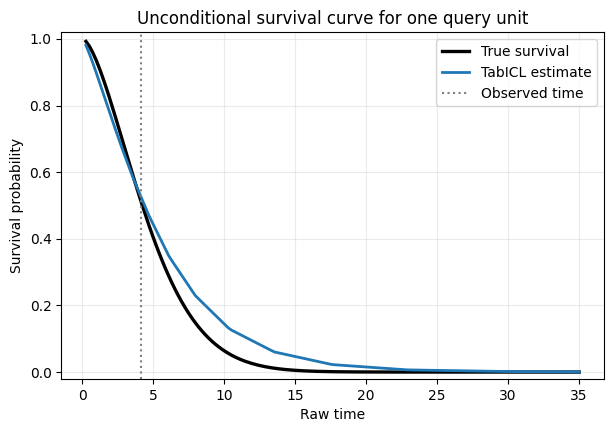

In [6]:
plt.figure(figsize=(7, 4.5))
plt.plot(time_grid, true_surv, label="True survival", linewidth=2.4, color="black")
if estimator is not None:
    plt.plot(time_grid, estimated_surv, label="TabICL estimate", linewidth=2)
plt.axvline(t_query_obs[query_idx], color="gray", linestyle=":", label="Observed time")
plt.ylim(-0.02, 1.02)
plt.xlabel("Raw time")
plt.ylabel("Survival probability")
plt.title("Unconditional survival curve for one query unit")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 5. Conditional Survival After a Landmark Time

If a row is known to be event-free up to time `c`, the conditional survival curve is

\[
S(t \mid T > c, X) = 1 \quad (t \le c), \qquad S(t \mid X) / S(c \mid X) \quad (t > c).
\]

The wrapper applies this conditioning as a post-model survival-curve transformation.


In [7]:
censored_positions = np.flatnonzero(delta_query == 0)
cond_idx = int(censored_positions[0])
x_censored = X_query.iloc[[cond_idx]]
x_censored_raw = x_censored.iloc[0].to_numpy(dtype=np.float32)
c = float(t_query_obs[cond_idx])

true_unconditional = true_survival_weibull_ph(time_grid, x_censored_raw, true_params)
s_c = float(true_survival_weibull_ph(np.array([c], dtype=np.float32), x_censored_raw, true_params)[0])
true_conditional = np.where(time_grid <= c, 1.0, true_unconditional / max(s_c, 1e-8))
true_conditional = np.clip(true_conditional, 0.0, 1.0)

if estimator is not None:
    estimated_conditional = estimator.predict_survival_function(
        x_censored,
        times=time_grid,
        conditional_time=np.array([c], dtype=np.float32),
    )[0]
else:
    estimated_conditional = np.full_like(true_conditional, np.nan)

print(f"Censored query row: {cond_idx}")
print(f"Landmark/censoring time c: {c:.3f}")
print(f"Privileged true event time: {t_query_event[cond_idx]:.3f}")


Censored query row: 6
Landmark/censoring time c: 25.018
Privileged true event time: 32.878


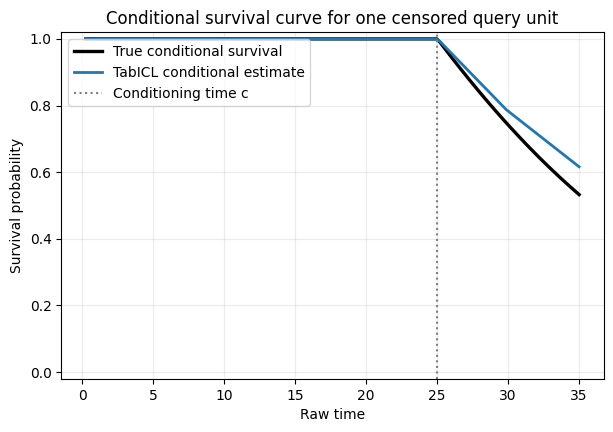

In [8]:
plt.figure(figsize=(7, 4.5))
plt.plot(time_grid, true_conditional, label="True conditional survival", linewidth=2.4, color="black")
if estimator is not None:
    plt.plot(time_grid, estimated_conditional, label="TabICL conditional estimate", linewidth=2)
plt.axvline(c, color="gray", linestyle=":", label="Conditioning time c")
plt.ylim(-0.02, 1.02)
plt.xlabel("Raw time")
plt.ylabel("Survival probability")
plt.title("Conditional survival curve for one censored query unit")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 6. Quantile and Median Prediction

`predict` returns the median event time. `predict_quantiles` returns arbitrary event-time quantiles in raw time units.


In [9]:
quantile_levels = (0.1, 0.25, 0.5, 0.75, 0.9)
if estimator is not None:
    quantiles = estimator.predict_quantiles(x_one, quantile_levels=quantile_levels)[0]
    display(pd.DataFrame({"quantile_level": quantile_levels, "predicted_raw_time": quantiles}).round(3))
else:
    print("Skipping quantiles because the checkpoint is unavailable.")


,quantile_level,predicted_raw_time
0,0.10,0.963
1,0.25,2.144
2,0.50,4.356
3,0.75,7.596
4,0.90,11.595


## 7. Benchmark Design: Ranking vs Absolute Survival Calibration

The earlier benchmark can make misspecified parametric methods look surprisingly robust because all parametric models share the same PH covariate structure. If they learn a good linear predictor, they can rank patients well even with the wrong baseline distribution.

This section therefore focuses on **absolute survival probability calibration**. We still report C-index, but the main diagnostics are survival-curve metrics: IPCW Brier scores, Integrated Brier Score, calibration curves, predicted-vs-observed event probabilities, and synthetic oracle curve error.


In [10]:
BENCHMARK_PATH = REPO_ROOT / "scripts" / "benchmark_comparison.py"
spec = importlib.util.spec_from_file_location("benchmark_comparison", BENCHMARK_PATH)
benchmark = importlib.util.module_from_spec(spec)
assert spec.loader is not None
sys.modules[spec.name] = benchmark
spec.loader.exec_module(benchmark)

benchmark.design_matrix()


Parametric PH model,Weibull,Gompertz,LogLogistic,LogNormal
Generated family,,,,
Weibull,correct,misspecified,misspecified,misspecified
Gompertz,misspecified,correct,misspecified,misspecified
LogLogistic,misspecified,misspecified,correct,misspecified
LogNormal,misspecified,misspecified,misspecified,correct


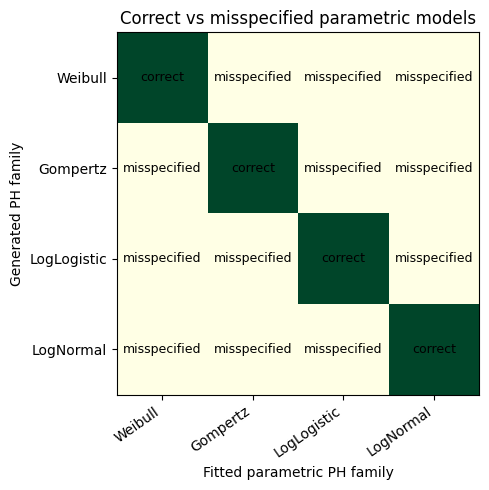

In [11]:
benchmark.plot_design_heatmap()
plt.show()


## 8. Run the Calibration-Focused Benchmark

We generate four PH datasets: Weibull, Gompertz, LogLogistic, and LogNormal. For each generated family, we fit:

- true oracle PH reference;
- TabICL, if the checkpoint is available;
- Kaplan-Meier;
- Cox PH;
- four fitted parametric PH models, one correctly specified and three misspecified.

The notebook uses two trials per generated family to keep runtime reasonable. Increase `n_trials` for a more stable formal comparison.


In [12]:
benchmark_config = benchmark.BenchmarkConfig(
    n_samples=768,
    n_features=5,
    n_context=512,
    n_trials=2,
    grid_size=100,
    checkpoint_path=CHECKPOINT_PATH,
    device="cpu",
    query_batch_size=64,
    skip_tabicl=not HAS_CHECKPOINT,
)

results, calibration, examples = benchmark.run_benchmark(benchmark_config)
summaries = benchmark.summarize_results(results)
calibration_gaps = benchmark.parametric_calibration_gaps(results)
print(f"Collected {len(results)} metric rows and {len(calibration)} calibration rows.")


[Weibull] trial 1/2
[Weibull] trial 2/2
[Gompertz] trial 1/2
[Gompertz] trial 2/2
[LogLogistic] trial 1/2
[LogLogistic] trial 2/2
[LogNormal] trial 1/2
[LogNormal] trial 2/2
Collected 192 metric rows and 854 calibration rows.


## 9. Calibration-Focused Summary

The table below puts survival-probability quality first. `brier_mean`, `ibs_mean`, `calibration_error_mean`, `oracle_ise_mean`, and `oracle_iae_mean` are all lower-is-better. C-index is retained as a ranking diagnostic, not the main target.


In [13]:
display(summaries["calibration"])


ibs_mean  \
data_family model                       model_type      specification               
Gompertz    Cox PH                      semi_parametric semi_parametric    0.1240   
            Kaplan-Meier                non_parametric  non_parametric     0.1872   
            Oracle PH (Gompertz)        oracle          oracle             0.1219   
            Parametric PH (Gompertz)    parametric      correct            0.1223   
            Parametric PH (LogLogistic) parametric      misspecified       0.1245   
            Parametric PH (LogNormal)   parametric      misspecified       0.1265   
            Parametric PH (Weibull)     parametric      misspecified       0.1224   
            TabICL                      icl             icl                0.1240   
LogLogistic Cox PH                      semi_parametric semi_parametric    0.1360   
            Kaplan-Meier                non_parametric  non_parametric     0.1915   
            Oracle PH (LogLogistic)     oracle          oracle             0.1359   
            Parametric PH (Gompertz)    parametric      misspecified       0.1459   
            Parametric PH (LogLogistic) parametric      correct            0.1368   
            Parametric PH (LogNormal)   parametric      misspecified       0.1382   
            Parametric PH (Weibull)     parametric      misspecified       0.1472   
            TabICL                      icl             icl                0.1390   
LogNormal   Cox PH                      semi_parametric semi_parametric    0.1311   
            Kaplan-Meier                non_parametric  non_parametric     0.2115   
            Oracle PH (LogNormal)       oracle          oracle             0.1246   
            Parametric PH (Gompertz)    parametric      misspecified       0.1298   
            Parametric PH (LogLogistic) parametric      misspecified       0.1299   
            Parametric PH (LogNormal)   parametric      correct            0.1281   
            Parametric PH (Weibull)     parametric      misspecified       0.1292   
            TabICL                      icl             icl                0.1300   
Weibull     Cox PH                      semi_parametric semi_parametric    0.1398   
            Kaplan-Meier                non_parametric  non_parametric     0.2086   
            Oracle PH (Weibull)         oracle          oracle             0.1374   
            Parametric PH (Gompertz)    parametric      misspecified       0.1378   
            Parametric PH (LogLogistic) parametric      misspecified       0.1370   
            Parametric PH (LogNormal)   parametric      misspecified       0.1383   
            Parametric PH (Weibull)     parametric      correct            0.1367   
            TabICL                      icl             icl                0.1396   

                                                                         brier_mean  \
data_family model                       model_type      specification                 
Gompertz    Cox PH                      semi_parametric semi_parametric      0.1550   
            Kaplan-Meier                non_parametric  non_parametric       0.2163   
            Oracle PH (Gompertz)        oracle          oracle               0.1540   
            Parametric PH (Gompertz)    parametric      correct              0.1546   
            Parametric PH (LogLogistic) parametric      misspecified         0.1561   
            Parametric PH (LogNormal)   parametric      misspecified         0.1583   
            Parametric PH (Weibull)     parametric      misspecified         0.1546   
            TabICL                      icl             icl                  0.1561   
LogLogistic Cox PH                      semi_parametric semi_parametric      0.1522   
            Kaplan-Meier                non_parametric  non_parametric       0.2026   
            Oracle PH (LogLogistic)     oracle          oracle               0.1516   
            Parametric PH (Gompertz)    parametric 

The next table compresses the parametric comparison into **correct vs misspecified gaps**. Positive gaps mean the misspecified parametric models are worse on average than the correctly specified parametric model for that generated family.


In [14]:
display(calibration_gaps)


,ibs_correct,ibs_misspecified_mean,ibs_gap,brier_correct,brier_misspecified_mean,brier_gap,calibration_error_correct,calibration_error_misspecified_mean,calibration_error_gap,oracle_ise_correct,oracle_ise_misspecified_mean,oracle_ise_gap,oracle_iae_correct,oracle_iae_misspecified_mean,oracle_iae_gap
data_family,,,,,,,,,,,,,,,
Gompertz,0.1223,0.1245,0.0022,0.1546,0.1563,0.0017,0.0392,0.0482,0.0090,0.0005,0.0021,0.0016,0.0161,0.0324,0.0163
LogLogistic,0.1368,0.1437,0.0069,0.1526,0.1580,0.0054,0.0480,0.0700,0.0221,0.0005,0.0042,0.0037,0.0164,0.0463,0.0300
LogNormal,0.1281,0.1296,0.0016,0.1408,0.1428,0.0020,0.0508,0.0603,0.0095,0.0014,0.0039,0.0025,0.0262,0.0445,0.0184
Weibull,0.1367,0.1377,0.0010,0.1371,0.1385,0.0014,0.0396,0.0468,0.0072,0.0005,0.0016,0.0011,0.0158,0.0297,0.0140


## 10. Survival-Curve Error Visuals

These figures are intended to show why baseline misspecification matters more for absolute survival curves than for risk ranking.


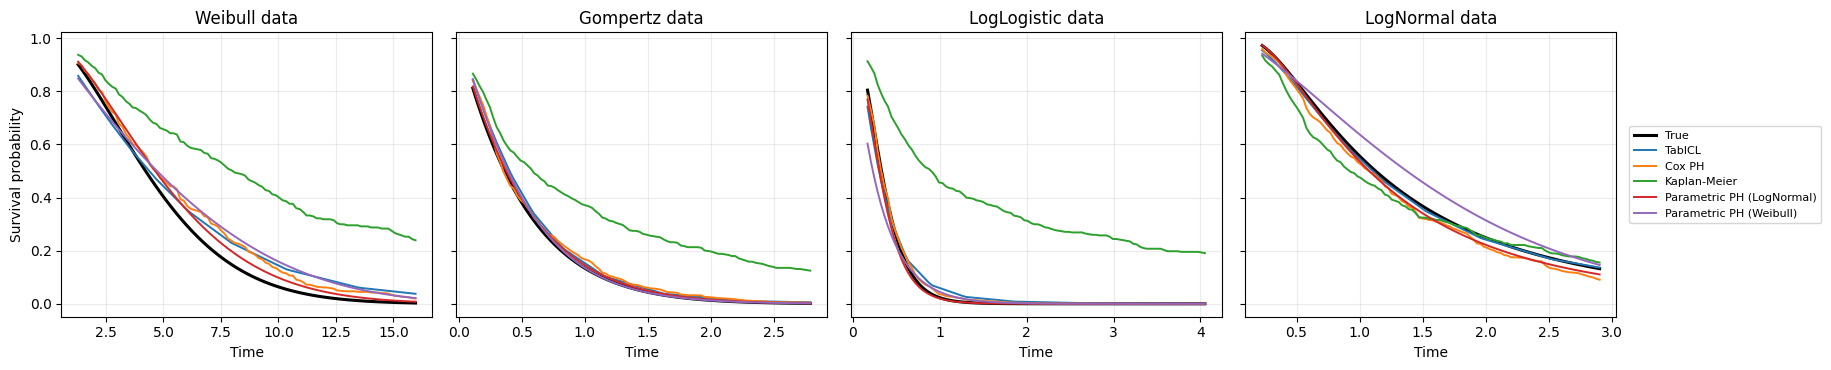

In [15]:
benchmark.plot_survival_examples(examples)
plt.show()


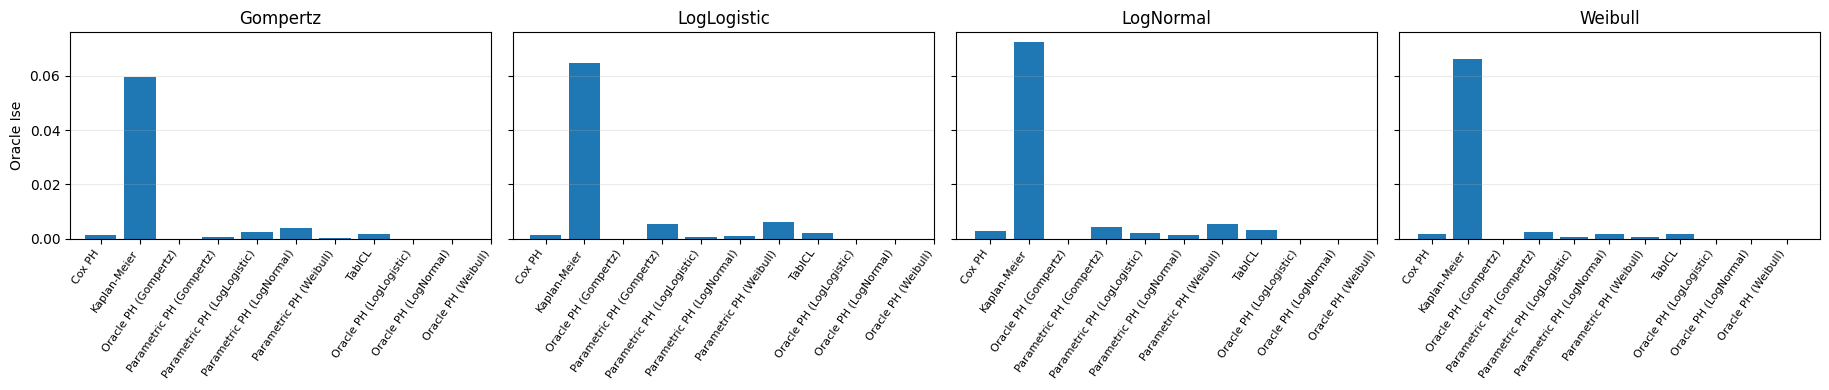

In [16]:
benchmark.plot_metric_bars(results, "oracle_ise")
plt.show()


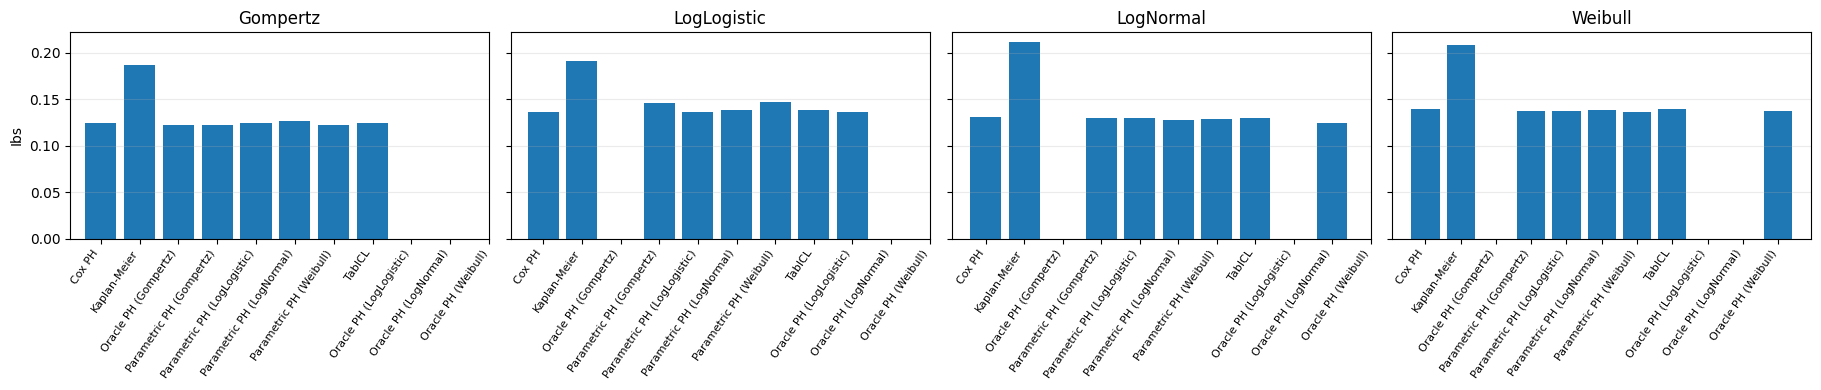

In [17]:
benchmark.plot_metric_bars(results, "ibs")
plt.show()


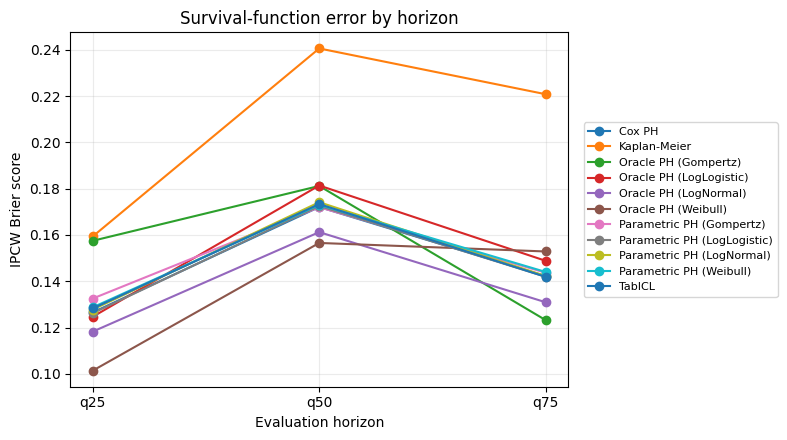

In [18]:
benchmark.plot_brier_horizons(results)
plt.show()


## 11. Calibration Visuals

Calibration plots compare predicted event probability `1 - S(t | X)` with IPCW-observed event frequency. Points or curves near the diagonal are better calibrated.


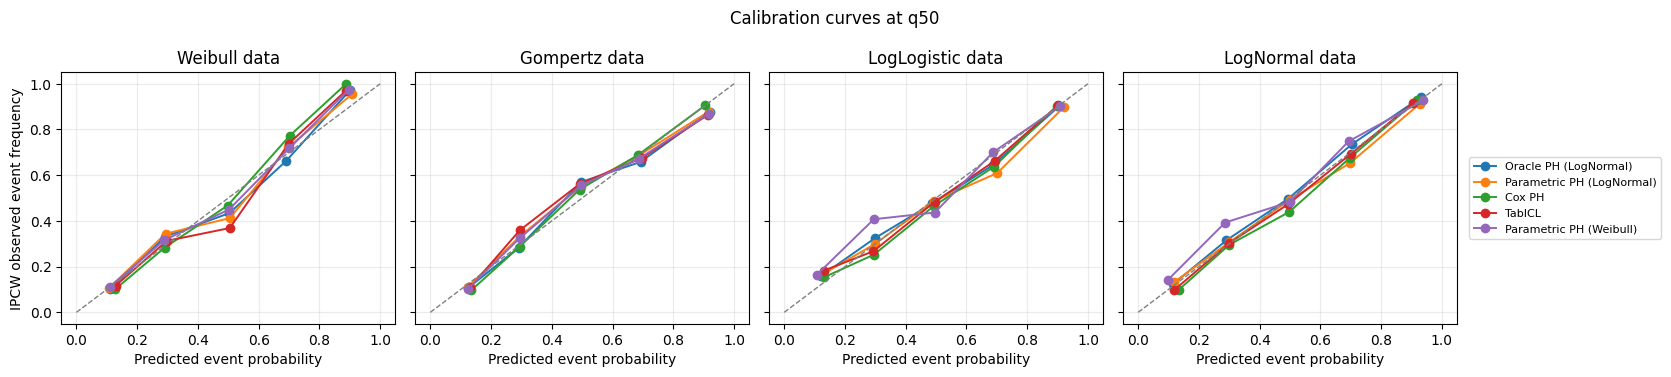

In [19]:
benchmark.plot_calibration_by_family(calibration, horizon_label="q50")
plt.show()


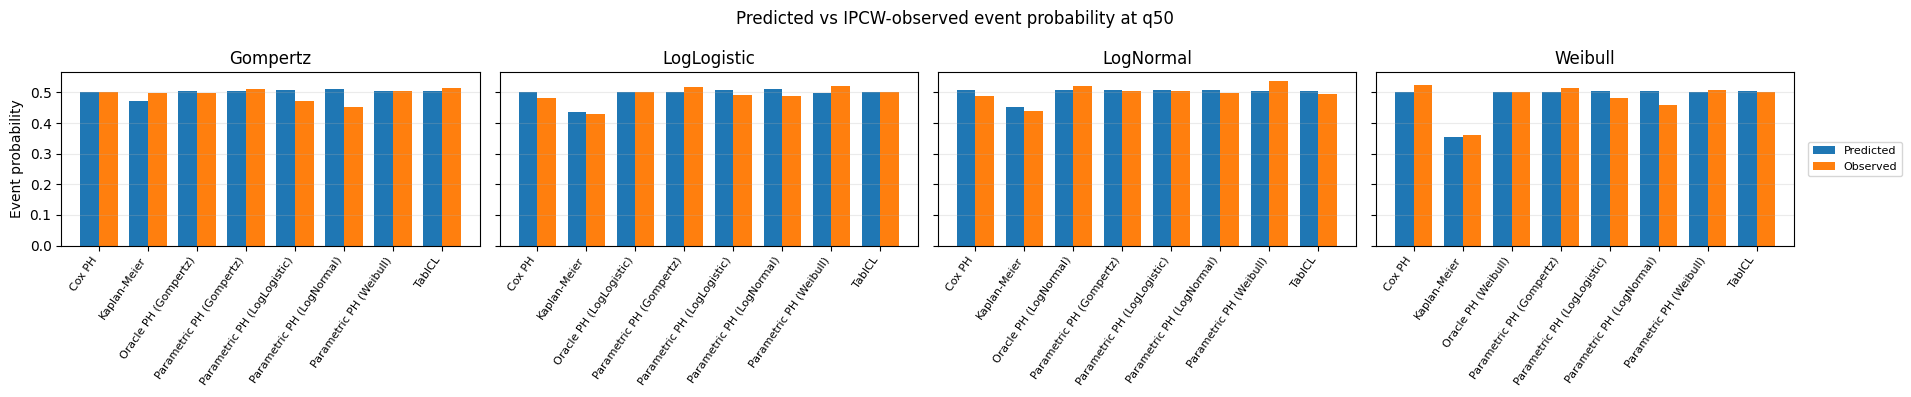

In [20]:
benchmark.plot_predicted_observed_event_bars(calibration, horizon_label="q50")
plt.show()


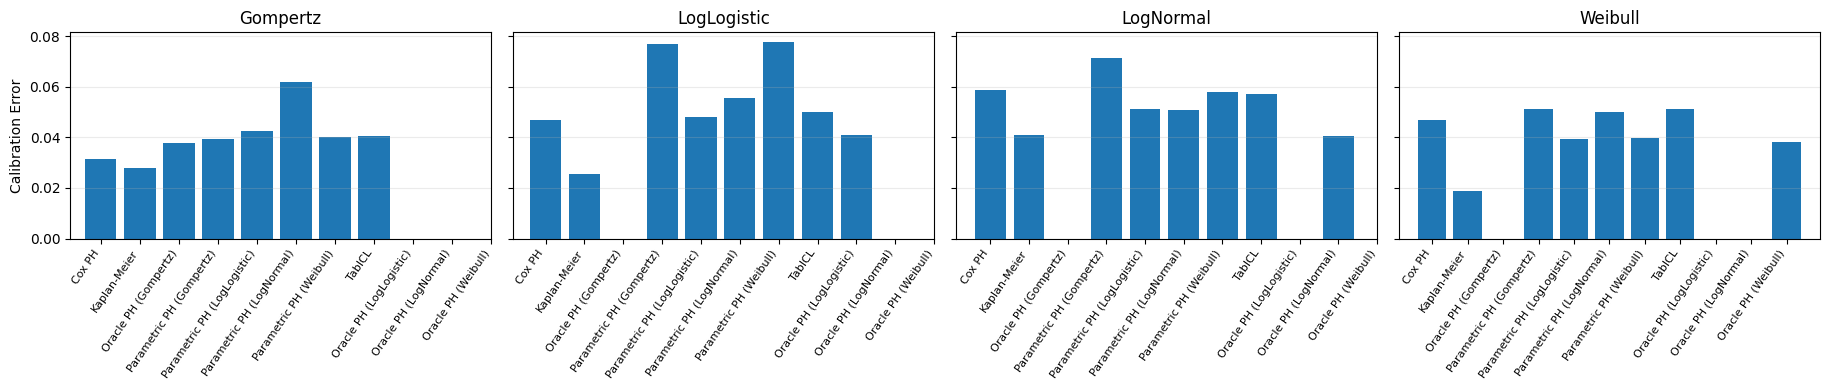

In [21]:
benchmark.plot_calibration_error_bars(results)
plt.show()


## 12. Ranking Diagnostic

C-index remains useful, but it primarily measures discrimination. If misspecified parametric PH models learn a similar covariate effect, their C-index can remain high even when their absolute survival probabilities are less well calibrated.


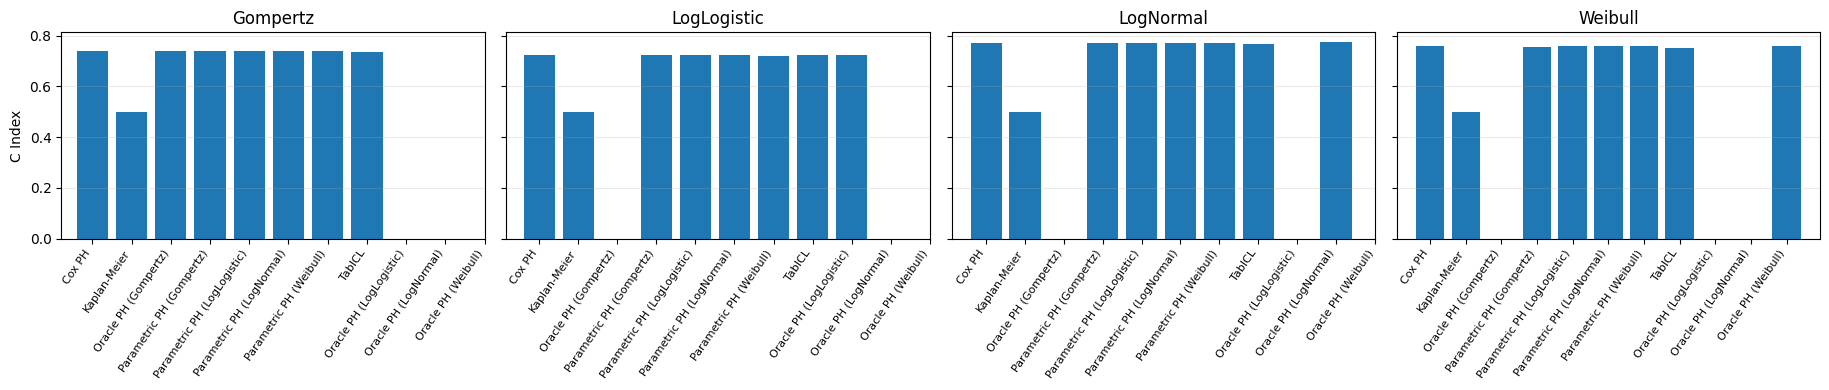

In [22]:
benchmark.plot_metric_bars(results, "c_index")
plt.show()


## 13. Interpretation Guide

- PH baseline misspecification may not strongly hurt C-index because C-index mostly depends on the learned covariate ranking.
- Absolute survival probability metrics are more sensitive to baseline shape: IBS, Brier scores, calibration curves, and oracle curve error reveal where the wrong baseline family distorts `S(t | X)`.
- Cox PH can rank well without a parametric baseline, but its absolute survival curve still depends on the estimated baseline hazard.
- Kaplan-Meier can be reasonably calibrated for population survival but ignores covariates, so it cannot adapt individual survival probabilities.
- TabICL is evaluated without per-task gradient updates; its calibration should be read against both the oracle curve and fitted classical baselines.
